In [1]:
import numpy as np
from ofdm.metrics import calculate_cm
from ofdm.plots import plot_ccdf, plot_ccdf_compare
import torch
from nnscf import NNSCFMapper, device, denormalize
import os

In [2]:
samples_per_L = 10000
data_size = 100
train_size = 70
val_size = 10
test_size = data_size - train_size - val_size
raw_dir = "./raw/"
norm_dir = "./norm/"
relev_dir = "./relev/"

one_batch = None
loop_range = range(data_size - test_size, data_size)
if one_batch:
    loop_range = [int(one_batch)]

In [3]:
# 1. Load the Saved Models
Old_Mod_Re = NNSCFMapper().to(device)
Old_Mod_Im = NNSCFMapper().to(device)
Old_Mod_Re.load_state_dict(torch.load(os.path.join(relev_dir, f"old_method_weights_re.pth"), weights_only=True))
Old_Mod_Im.load_state_dict(torch.load(os.path.join(relev_dir, f"old_method_weights_im.pth"), weights_only=True))
Old_Mod_Re.eval()
Old_Mod_Im.eval()

NNSCFMapper(
  (hidden1): Linear(in_features=1, out_features=2, bias=True)
  (hidden2): Linear(in_features=2, out_features=1, bias=True)
  (output): Linear(in_features=1, out_features=1, bias=True)
  (activation): TriangularActivation()
)

In [4]:
checkpoint_re = torch.load(
    os.path.join(relev_dir, f"new_method_weights_limits_re.pth"),
    weights_only=False
)
checkpoint_im = torch.load(
    os.path.join(relev_dir, f"new_method_weights_limits_im.pth"),
    weights_only=False
)
New_Mod_Re = NNSCFMapper().to(device)
New_Mod_Im = NNSCFMapper().to(device)
New_Mod_Re.load_state_dict(checkpoint_re['model_state_dict'])
New_Mod_Im.load_state_dict(checkpoint_im['model_state_dict'])
New_Mod_Re.eval()
New_Mod_Im.eval()

X_r_min = checkpoint_re['X_min']
X_r_max = checkpoint_re['X_max']
Y_r_min = checkpoint_re['Y_min']
Y_r_max = checkpoint_re['Y_max']

X_i_min = checkpoint_im['X_min']
X_i_max = checkpoint_im['X_max']
Y_i_min = checkpoint_im['Y_min']
Y_i_max = checkpoint_im['Y_max']

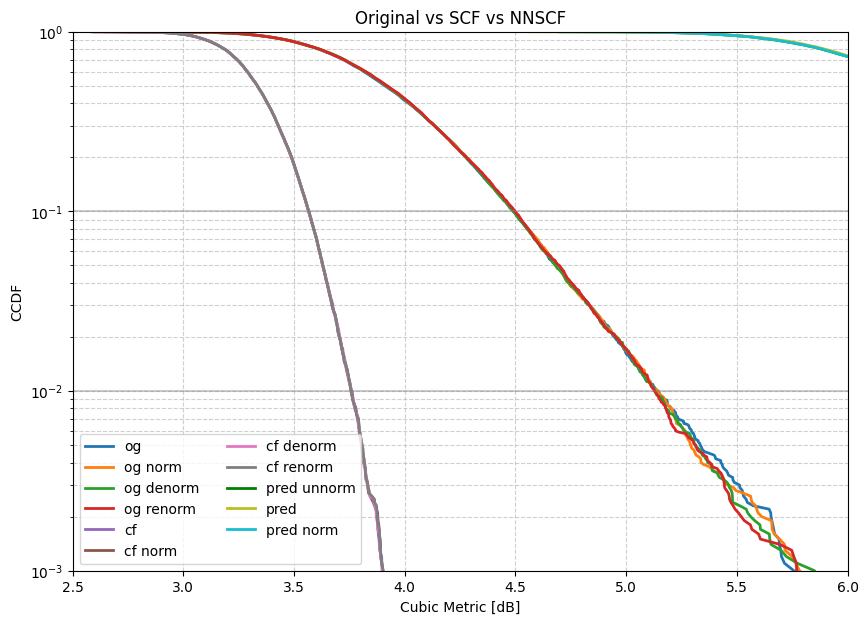

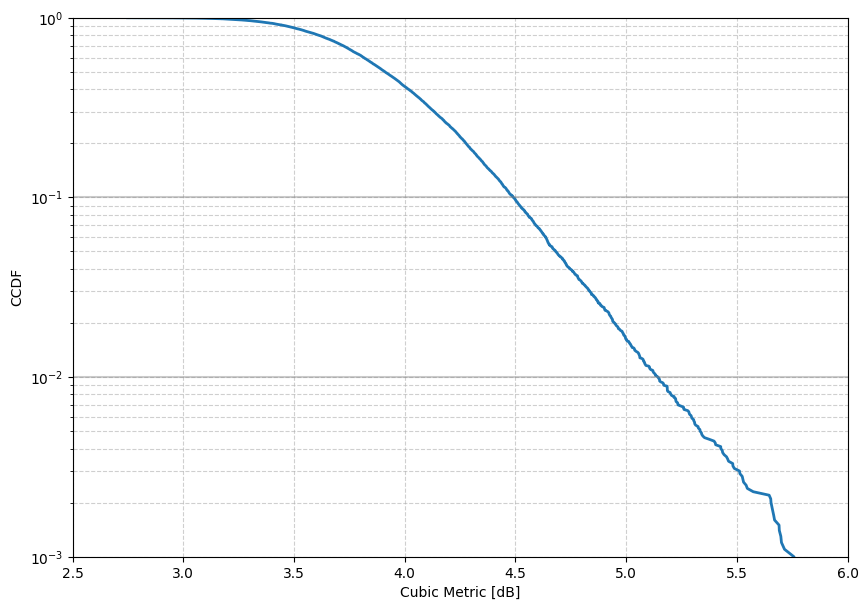

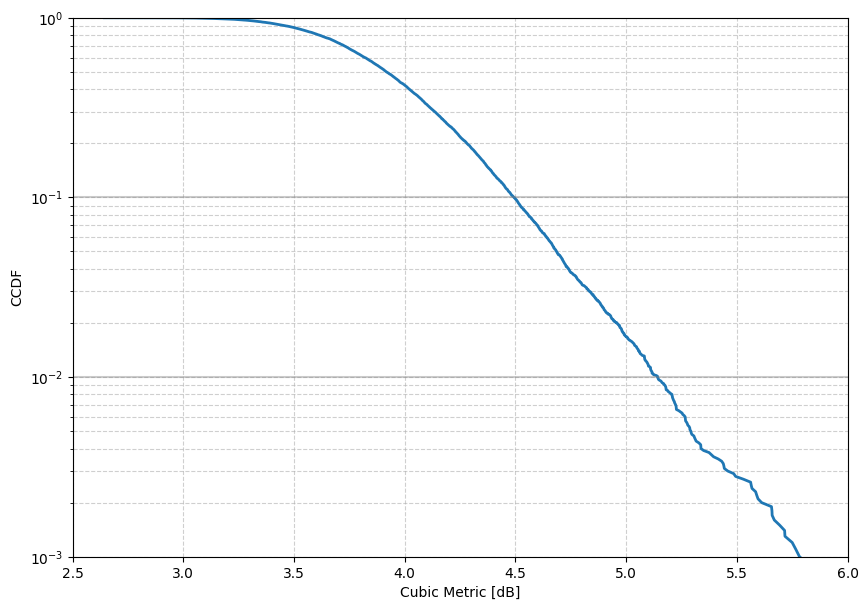

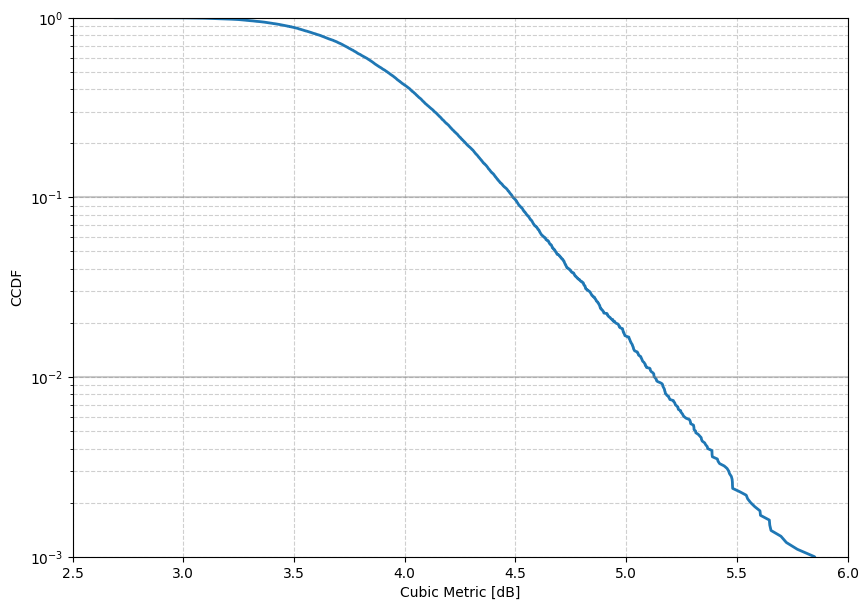

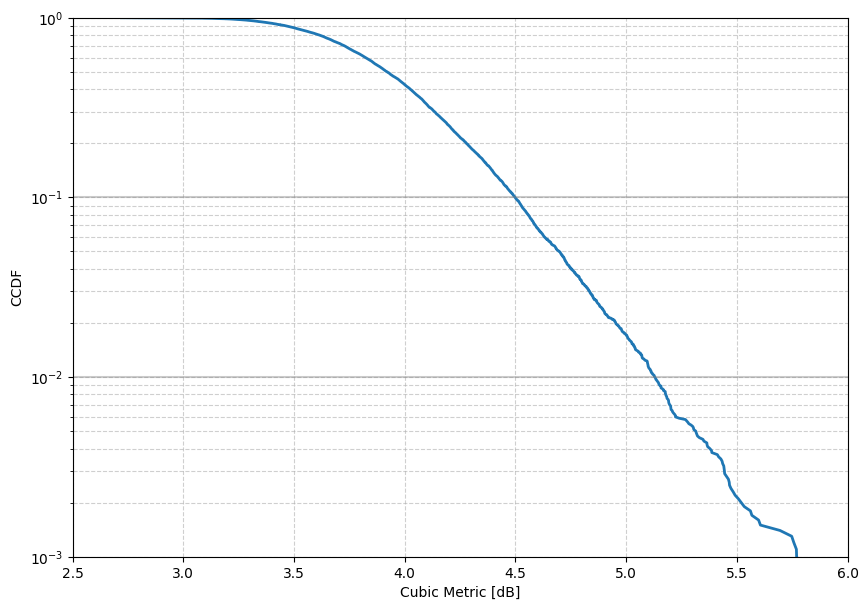

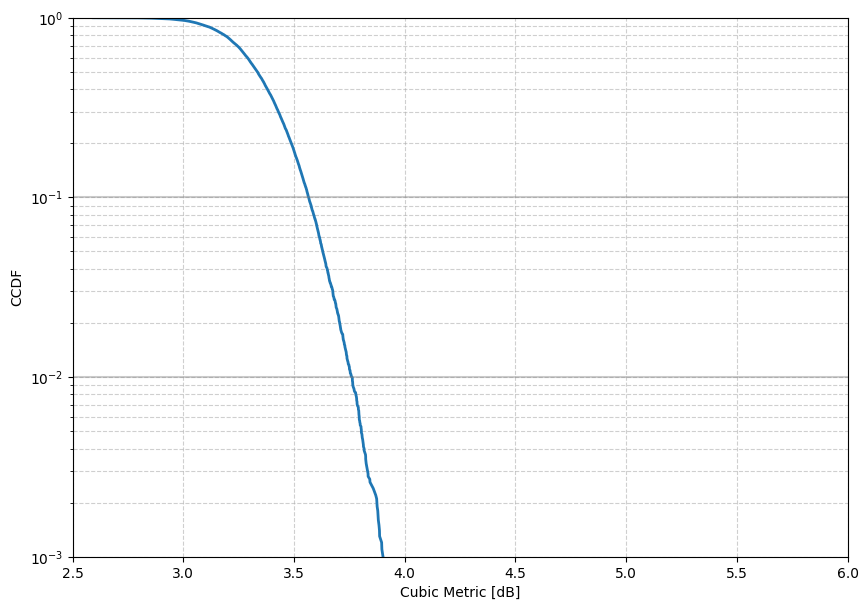

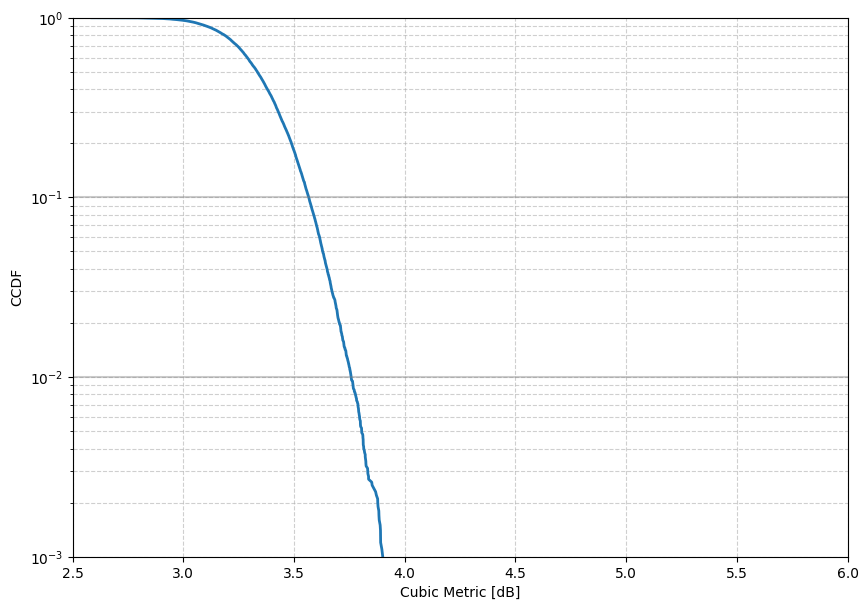

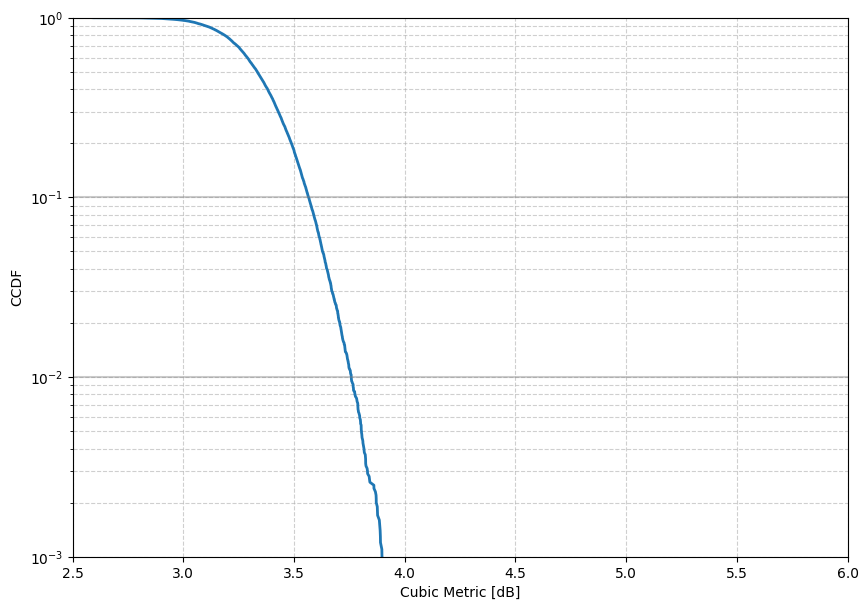

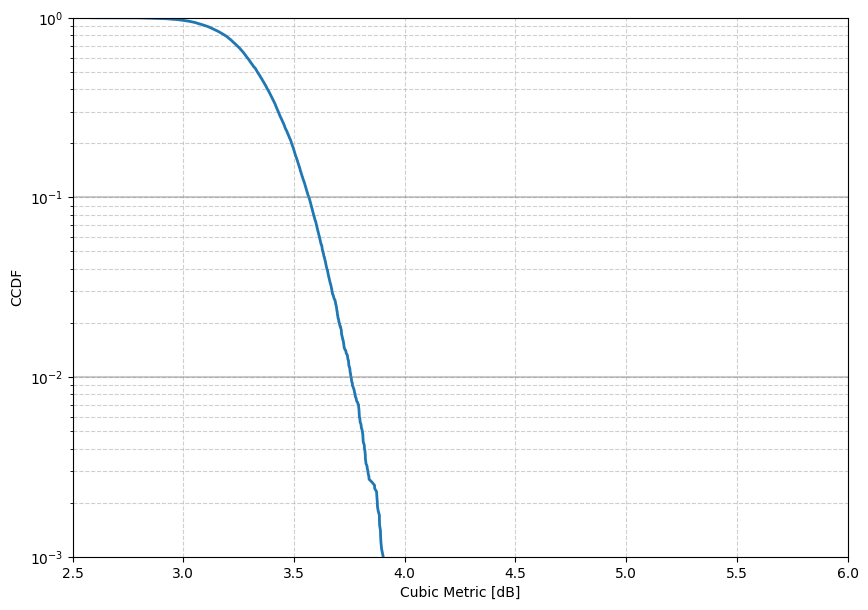

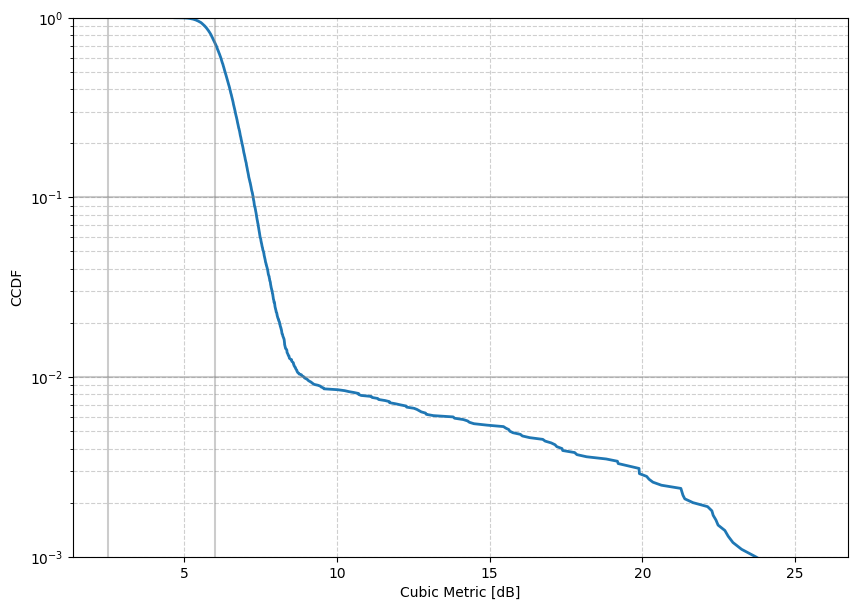

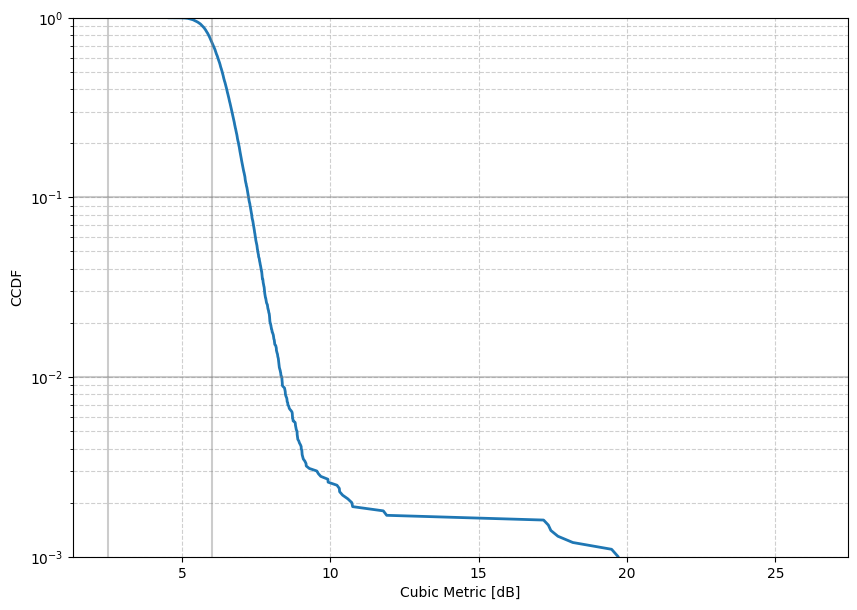

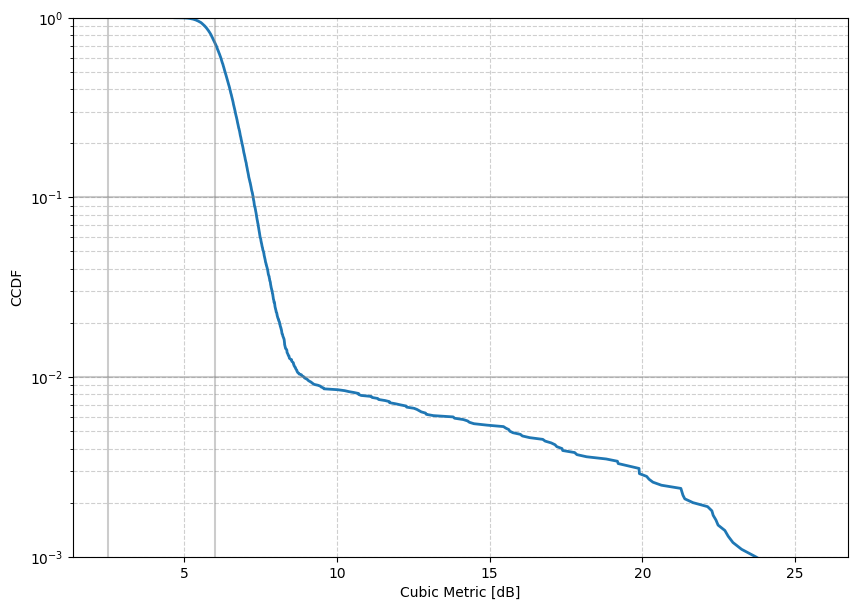

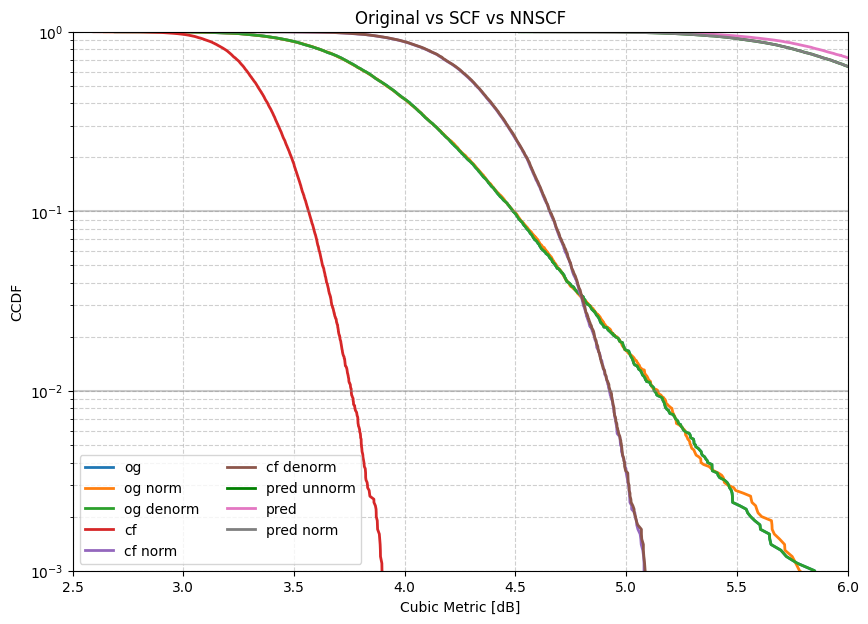

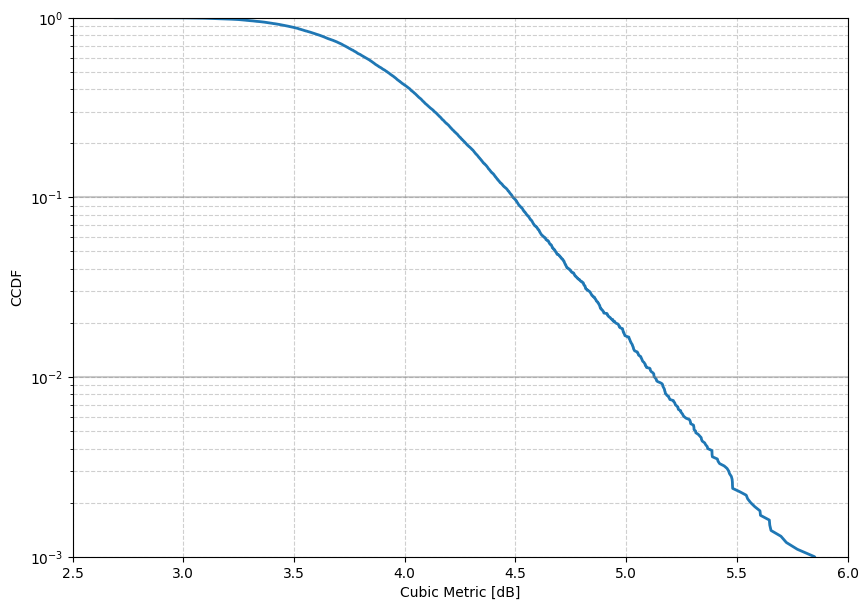

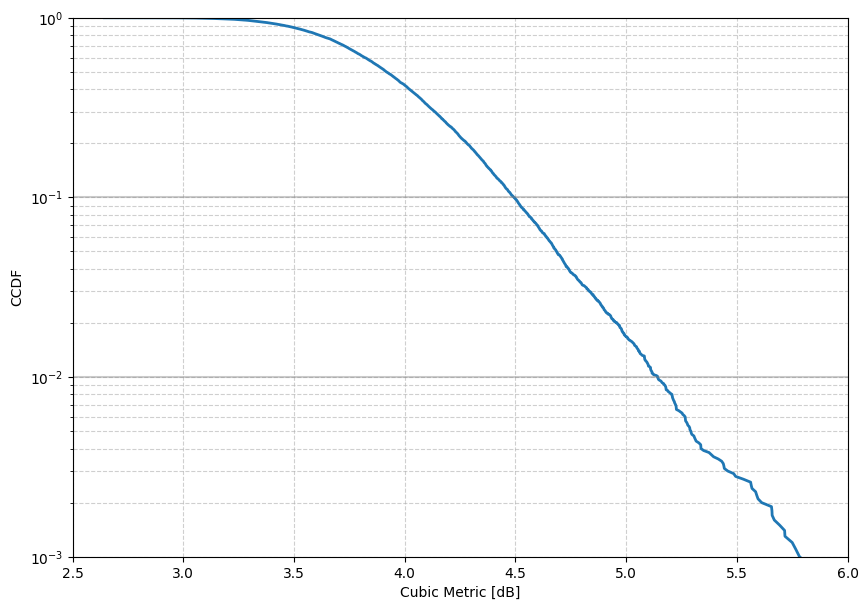

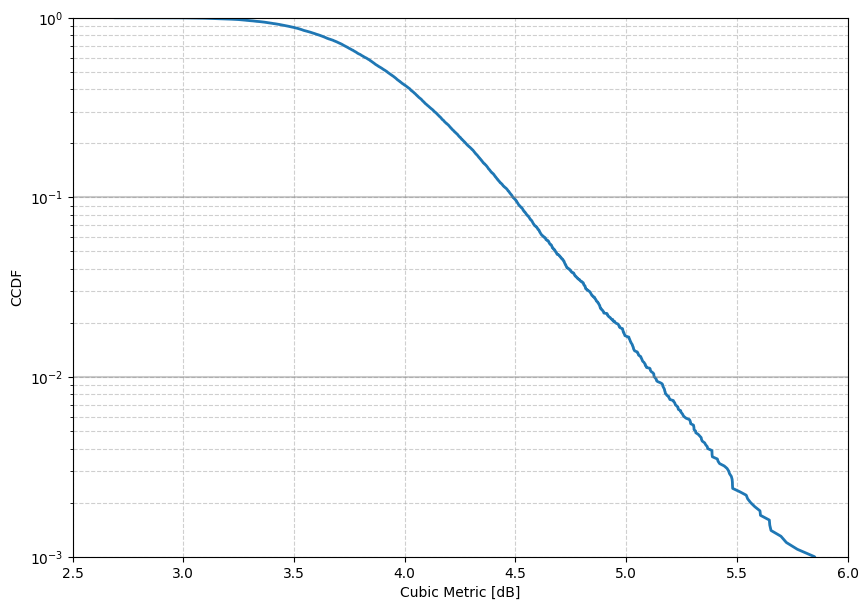

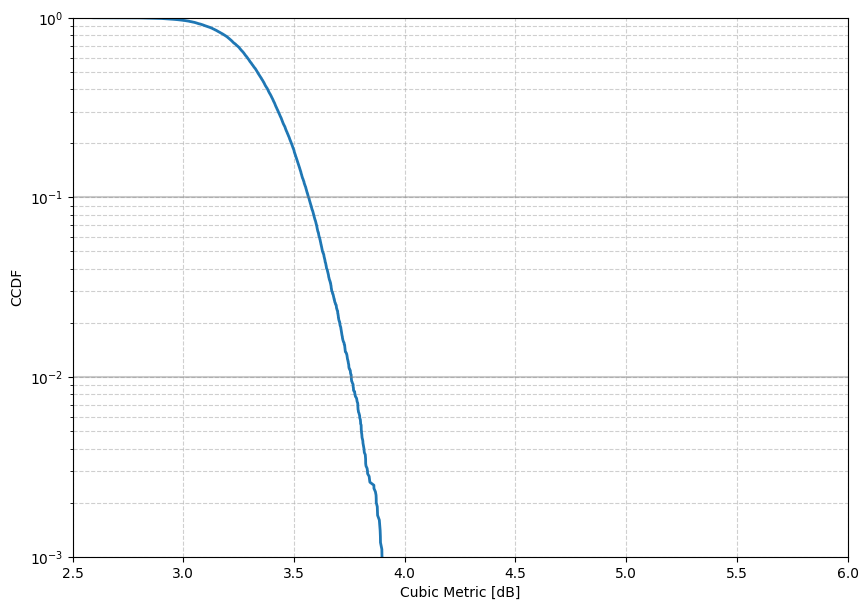

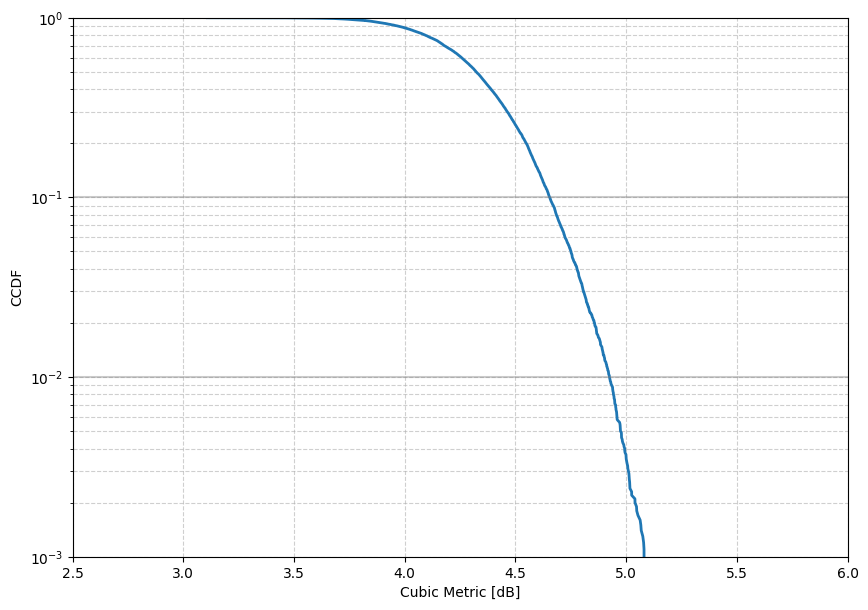

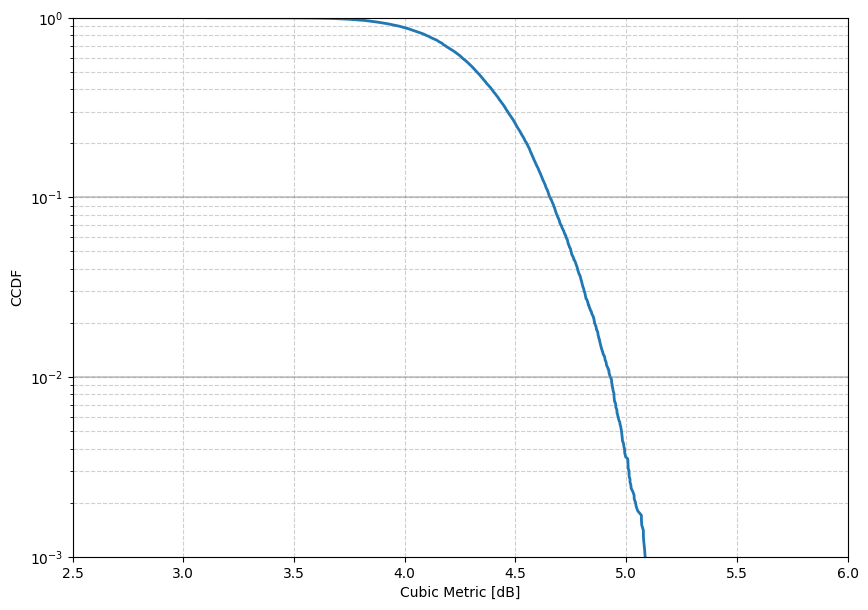

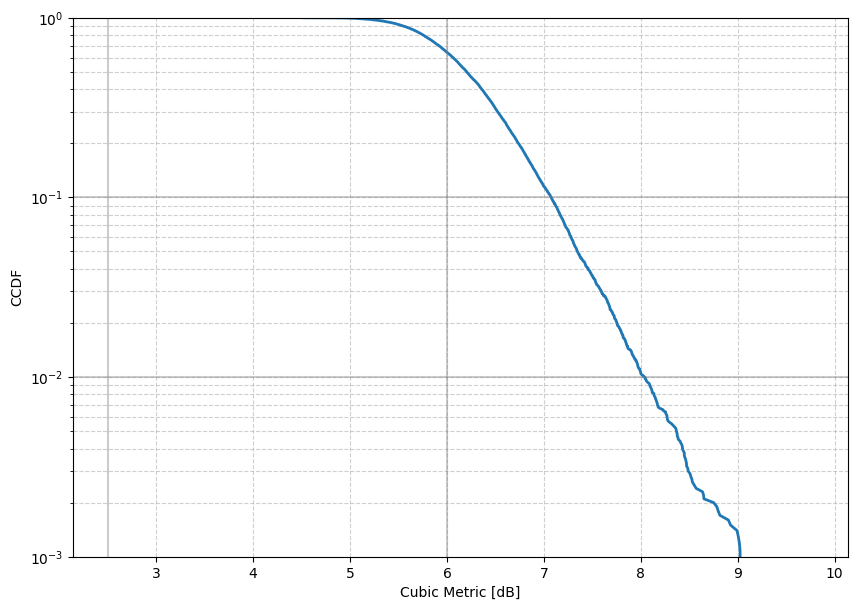

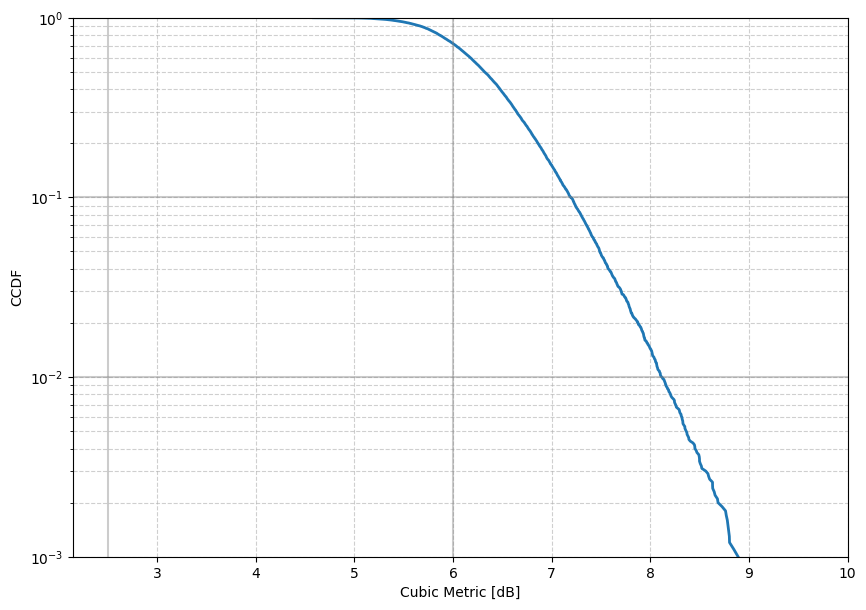

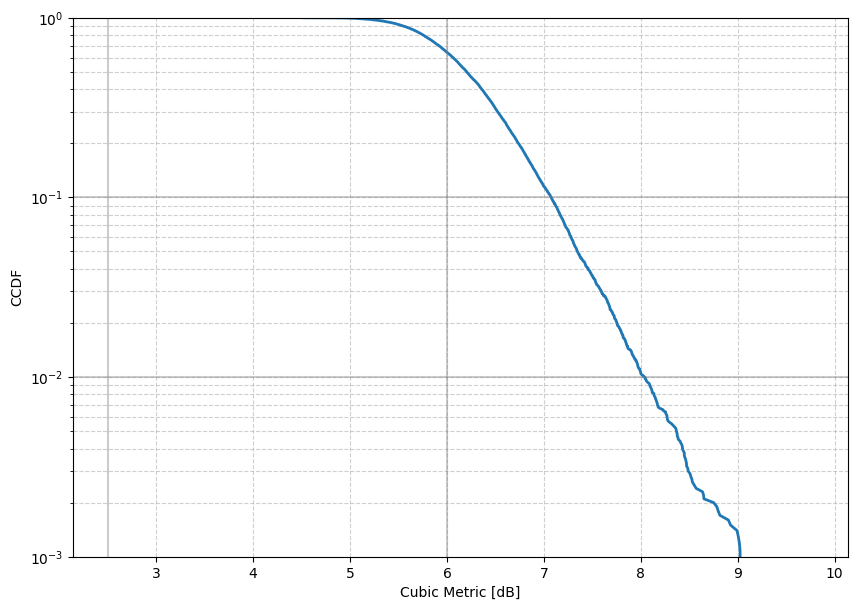

In [5]:
for i in loop_range:
    # 2. Grab one batch of data to test (Load the dictionary packages)
    pkg_real_old = torch.load(os.path.join(raw_dir, f"old_method_{i:02}_real.pt"), weights_only=False)
    pkg_imag_old = torch.load(os.path.join(raw_dir, f"old_method_{i:02}_imag.pt"), weights_only=False)
    pkg_real_norm_old = torch.load(os.path.join(norm_dir, f"old_method_{i:02}_real.pt"), weights_only=False)
    pkg_imag_norm_old = torch.load(os.path.join(norm_dir, f"old_method_{i:02}_imag.pt"), weights_only=False)

    pkg_real_new = torch.load(os.path.join(raw_dir, f"new_method_{i:02}_real.pt"), weights_only=False)
    pkg_imag_new = torch.load(os.path.join(raw_dir, f"new_method_{i:02}_imag.pt"), weights_only=False)
    pkg_real_norm_new = torch.load(os.path.join(norm_dir, f"new_method_{i:02}_real.pt"), weights_only=False)
    pkg_imag_norm_new = torch.load(os.path.join(norm_dir, f"new_method_{i:02}_imag.pt"), weights_only=False)


    # Extract tensors
    test_X_real_old = pkg_real_old['X_norm']
    test_Y_real_old = pkg_real_old['Y_norm']
    test_X_imag_old = pkg_imag_old['X_norm']
    test_Y_imag_old = pkg_imag_old['Y_norm']
    test_X_real_norm_old = pkg_real_norm_old['X_norm']
    test_Y_real_norm_old = pkg_real_norm_old['Y_norm']
    test_X_imag_norm_old = pkg_imag_norm_old['X_norm']
    test_Y_imag_norm_old = pkg_imag_norm_old['Y_norm']

    test_X_real_new = pkg_real_new['X_raw']
    test_Y_real_new = pkg_real_new['Y_raw']
    test_X_imag_new = pkg_imag_new['X_raw']
    test_Y_imag_new = pkg_imag_new['Y_raw']
    test_X_real_norm_new = pkg_real_norm_new['X_norm']
    test_Y_real_norm_new = pkg_real_norm_new['Y_norm']
    test_X_imag_norm_new = pkg_imag_norm_new['X_norm']
    test_Y_imag_norm_new = pkg_imag_norm_new['Y_norm']


    # 3. Generate Predictions (Reshape, Predict, Reshape back)
    with torch.no_grad():
        # Memoryless flattening
        X_real_flat_old = test_X_real_old.view(-1, 1).to(device)
        X_imag_flat_old = test_X_imag_old.view(-1, 1).to(device)
        X_real_flat_norm_old = test_X_real_norm_old.view(-1, 1).to(device)
        X_imag_flat_norm_old = test_X_imag_norm_old.view(-1, 1).to(device)

        X_real_flat_new = test_X_real_new.view(-1, 1).to(device)
        X_imag_flat_new = test_X_imag_new.view(-1, 1).to(device)
        X_real_flat_norm_new = test_X_real_norm_new.view(-1, 1).to(device)
        X_imag_flat_norm_new = test_X_imag_norm_new.view(-1, 1).to(device)


        predicted_real_unnorm_old = Old_Mod_Re(X_real_flat_old).view_as(test_X_real_old).cpu().numpy()
        predicted_imag_unnorm_old = Old_Mod_Im(X_imag_flat_old).view_as(test_X_imag_old).cpu().numpy()
        predicted_real_old = Old_Mod_Re(X_real_flat_norm_old).view_as(test_X_real_norm_old).cpu().numpy()
        predicted_imag_old = Old_Mod_Im(X_imag_flat_norm_old).view_as(test_X_imag_norm_old).cpu().numpy()

        predicted_real_unnorm_new = New_Mod_Re(X_real_flat_new).view_as(test_X_real_new).cpu().numpy()
        predicted_imag_unnorm_new = New_Mod_Im(X_imag_flat_new).view_as(test_X_imag_new).cpu().numpy()
        predicted_real_new = New_Mod_Re(X_real_flat_norm_new).view_as(test_X_real_norm_new).cpu().numpy()
        predicted_imag_new = New_Mod_Im(X_imag_flat_norm_new).view_as(test_X_imag_norm_new).cpu().numpy()

    # Denormalize
    test_X_real_denorm_old = denormalize(test_X_real_old, (pkg_real_old['X_min'], pkg_real_old['X_max']))
    test_X_imag_denorm_old = denormalize(test_X_imag_old, (pkg_imag_old['X_min'], pkg_imag_old['X_max']))
    test_Y_real_denorm_old = denormalize(test_Y_real_old, (pkg_real_old['Y_min'], pkg_real_old['Y_max']))
    test_Y_imag_denorm_old = denormalize(test_Y_imag_old, (pkg_imag_old['Y_min'], pkg_imag_old['Y_max']))
    test_X_real_renorm_old = denormalize(test_X_real_norm_old, (pkg_real_old['X_min'], pkg_real_old['X_max']))
    test_X_imag_renorm_old = denormalize(test_X_imag_norm_old, (pkg_imag_old['X_min'], pkg_imag_old['X_max']))
    test_Y_real_renorm_old = denormalize(test_Y_real_norm_old, (pkg_real_old['Y_min'], pkg_real_old['Y_max']))
    test_Y_imag_renorm_old = denormalize(test_Y_imag_norm_old, (pkg_imag_old['Y_min'], pkg_imag_old['Y_max']))
    pred_denorm_real_old = denormalize(predicted_real_old, (pkg_real_old['Y_min'], pkg_real_old['Y_max']))
    pred_denorm_imag_old = denormalize(predicted_imag_old, (pkg_imag_old['Y_min'], pkg_imag_old['Y_max']))

    test_X_real_denorm_new = denormalize(test_X_real_norm_new, (X_r_min, X_r_max))
    test_X_imag_denorm_new = denormalize(test_X_imag_norm_new, (X_i_min, X_i_max))
    test_Y_real_denorm_new = denormalize(test_Y_real_norm_new, (Y_r_min, Y_r_max))
    test_Y_imag_denorm_new = denormalize(test_Y_imag_norm_new, (Y_i_min, Y_i_max))
    pred_denorm_real_new = denormalize(predicted_real_new, (Y_r_min, Y_r_max))
    pred_denorm_imag_new = denormalize(predicted_imag_new, (Y_i_min, Y_i_max))


    # 4. Reconstruct the Complex OFDM Signals
    original_complex_old = test_X_real_old.numpy() + 1j * test_X_imag_old.numpy()
    original_complex_norm_old = test_X_real_norm_old.numpy() + 1j * test_X_imag_norm_old.numpy()
    original_complex_denorm_old = test_X_real_denorm_old.numpy() + 1j * test_X_imag_denorm_old.numpy()
    original_complex_renorm_old = test_X_real_renorm_old.numpy() + 1j * test_X_imag_renorm_old.numpy()
    clipped_complex_old = test_Y_real_old.numpy() + 1j * test_Y_imag_old.numpy()
    clipped_complex_norm_old = test_Y_real_norm_old.numpy() + 1j * test_Y_imag_norm_old.numpy()
    clipped_complex_denorm_old = test_Y_real_denorm_old.numpy() + 1j * test_Y_imag_denorm_old.numpy()
    clipped_complex_renorm_old = test_Y_real_renorm_old.numpy() + 1j * test_Y_imag_renorm_old.numpy()
    predicted_complex_unnorm_old = predicted_real_unnorm_old + 1j * predicted_imag_unnorm_old
    predicted_complex_old = pred_denorm_real_old + 1j * pred_denorm_imag_old
    predicted_complex_norm_old = predicted_real_old + 1j * predicted_imag_old

    original_complex_new = test_X_real_new.numpy() + 1j * test_X_imag_new.numpy()
    original_complex_norm_new = test_X_real_norm_new.numpy() + 1j * test_X_imag_norm_new.numpy()
    original_complex_denorm_new = test_X_real_denorm_new.numpy() + 1j * test_X_imag_denorm_new.numpy()
    clipped_complex_new = test_Y_real_new.numpy() + 1j * test_Y_imag_new.numpy()
    clipped_complex_norm_new = test_Y_real_norm_new.numpy() + 1j * test_Y_imag_norm_new.numpy()
    clipped_complex_denorm_new = test_Y_real_denorm_new.numpy() + 1j * test_Y_imag_denorm_new.numpy()
    predicted_complex_unnorm_new = predicted_real_unnorm_new + 1j * predicted_imag_unnorm_new
    predicted_complex_new = pred_denorm_real_new + 1j * pred_denorm_imag_new
    predicted_complex_norm_new = predicted_real_new + 1j * predicted_imag_new

    # 5. Calculate PAPR and CM for CCDF
    orig_cm_old, orig_cm_norm_old, orig_cm_denorm_old, orig_cm_renorm_old, clip_cm_old, clip_cm_norm_old, clip_cm_denorm_old, clip_cm_renorm_old, pred_cm_unnorm_old, pred_cm_old, pred_cm_norm_old = [], [], [], [], [], [], [], [], [], [], []
    orig_cm_new, orig_cm_norm_new, orig_cm_denorm_new, clip_cm_new, clip_cm_norm_new, clip_cm_denorm_new, pred_cm_unnorm_new, pred_cm_new, pred_cm_norm_new = [], [], [], [], [], [], [], [], []

    # Iterate through the arrays
    for i in range(samples_per_L):
        orig_cm_old.append(calculate_cm(original_complex_old[i]))
        orig_cm_norm_old.append(calculate_cm(original_complex_norm_old[i]))
        orig_cm_denorm_old.append(calculate_cm(original_complex_denorm_old[i]))
        orig_cm_renorm_old.append(calculate_cm(original_complex_renorm_old[i]))
        clip_cm_old.append(calculate_cm(clipped_complex_old[i]))
        clip_cm_norm_old.append(calculate_cm(clipped_complex_norm_old[i]))
        clip_cm_denorm_old.append(calculate_cm(clipped_complex_denorm_old[i]))
        clip_cm_renorm_old.append(calculate_cm(clipped_complex_renorm_old[i]))
        pred_cm_unnorm_old.append(calculate_cm(predicted_complex_unnorm_old[i]))
        pred_cm_old.append(calculate_cm(predicted_complex_old[i]))
        pred_cm_norm_old.append(calculate_cm(predicted_complex_unnorm_old[i]))

        orig_cm_new.append(calculate_cm(original_complex_new[i]))
        orig_cm_norm_new.append(calculate_cm(original_complex_norm_new[i]))
        orig_cm_denorm_new.append(calculate_cm(original_complex_denorm_new[i]))
        clip_cm_new.append(calculate_cm(clipped_complex_new[i]))
        clip_cm_norm_new.append(calculate_cm(clipped_complex_norm_new[i]))
        clip_cm_denorm_new.append(calculate_cm(clipped_complex_denorm_new[i]))
        pred_cm_unnorm_new.append(calculate_cm(predicted_complex_unnorm_new[i]))
        pred_cm_new.append(calculate_cm(predicted_complex_new[i]))
        pred_cm_norm_new.append(calculate_cm(predicted_complex_unnorm_new[i]))

    orig_cm_old, orig_cm_norm_old, orig_cm_denorm_old, orig_cm_renorm_old, clip_cm_old, clip_cm_norm_old, clip_cm_denorm_old, clip_cm_renorm_old, pred_cm_unnorm_old, pred_cm_old, pred_cm_norm_old = np.array(orig_cm_old), np.array(orig_cm_norm_old), np.array(orig_cm_denorm_old), np.array(orig_cm_renorm_old), np.array(clip_cm_old), np.array(clip_cm_norm_old), np.array(clip_cm_denorm_old), np.array(clip_cm_renorm_old), np.array(pred_cm_unnorm_old), np.array(pred_cm_old), np.array(pred_cm_norm_old)
    orig_cm_new, orig_cm_norm_new, orig_cm_denorm_new, clip_cm_new, clip_cm_norm_new, clip_cm_denorm_new, pred_cm_unnorm_new, pred_cm_new, pred_cm_norm_new = np.array(orig_cm_new), np.array(orig_cm_norm_new), np.array(orig_cm_denorm_new), np.array(clip_cm_new), np.array(clip_cm_norm_new), np.array(clip_cm_denorm_new), np.array(pred_cm_unnorm_new), np.array(pred_cm_new), np.array(pred_cm_norm_new)

    # 6. Plot the CCDF
    labels_old = ['og', f'og norm', f'og denorm', f'og renorm', f'cf', f'cf norm', f'cf denorm', f'cf renorm', "pred unnorm", "pred", "pred norm"]
    labels_new = ['og', f'og norm', f'og denorm', f'cf', f'cf norm', f'cf denorm', "pred unnorm", "pred", "pred norm"]

    cm_list_old = [orig_cm_old, orig_cm_norm_old, orig_cm_denorm_old, orig_cm_renorm_old, clip_cm_old, clip_cm_norm_old, clip_cm_denorm_old, clip_cm_renorm_old, pred_cm_unnorm_old, pred_cm_old, pred_cm_norm_old]
    cm_list_new = [orig_cm_new, orig_cm_norm_new, orig_cm_denorm_new, clip_cm_new, clip_cm_norm_new, clip_cm_denorm_new, pred_cm_unnorm_new, pred_cm_new, pred_cm_norm_new]

    # fixme: both percentile and max are not the most efficient solutions

    # todo: find a way to embed the floor part into the plotting function
    # 1. Define the target y-levels (probabilities)
    cm_target_y = 1e-3

    # 2. Convert CCDF y-level to a standard percentile (e.g., 1e-4 becomes 99.99)
    cm_percentile = (1.0 - cm_target_y) * 100.0

    # 3. Extract the exact x-axis values (PAPR/CM) where the line cuts the graph
    # (This completely replaces the need for y_axis, np.where, and manual sorting!)

    cm_vlines_old = [
        np.percentile(orig_cm_old, cm_percentile),
        np.percentile(orig_cm_norm_old, cm_percentile),
        np.percentile(orig_cm_denorm_old, cm_percentile),
        np.percentile(orig_cm_renorm_old, cm_percentile),
        np.percentile(clip_cm_old, cm_percentile),
        np.percentile(clip_cm_norm_old, cm_percentile),
        np.percentile(clip_cm_denorm_old, cm_percentile),
        np.percentile(clip_cm_renorm_old, cm_percentile),
        np.percentile(pred_cm_unnorm_old, cm_percentile),
        np.percentile(pred_cm_old, cm_percentile),
        np.percentile(pred_cm_norm_old, cm_percentile)
    ]
    cm_vlines_new = [
        np.percentile(orig_cm_new, cm_percentile),
        np.percentile(orig_cm_norm_new, cm_percentile),
        np.percentile(orig_cm_denorm_new, cm_percentile),
        np.percentile(clip_cm_new, cm_percentile),
        np.percentile(clip_cm_norm_new, cm_percentile),
        np.percentile(clip_cm_denorm_new, cm_percentile),
        np.percentile(pred_cm_unnorm_new, cm_percentile),
        np.percentile(pred_cm_new, cm_percentile),
        np.percentile(pred_cm_norm_new, cm_percentile)
    ]

    # 4. Plot!
    cm_image_path_old = os.path.join(relev_dir, f"old_method_cm")
    plot_ccdf_compare(cm_list_old, f'Original vs SCF vs NNSCF', labels_old, metric="CM")
    for lst in cm_list_old:
        plot_ccdf(lst, metric="CM")
    cm_image_path_new = os.path.join(relev_dir, f"new_method_cm")
    plot_ccdf_compare(cm_list_new, f'Original vs SCF vs NNSCF', labels_new, metric="CM")
    for lst in cm_list_new:
        plot_ccdf(lst, metric="CM")